# Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.metrics import mean_squared_error
colo_pal = sns.color_palette()
plt.style.use('fivethirtyeight')
from math import sqrt

# pip install xgboost==1.6.2


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Data loading

In [2]:
# df = pd.read_csv('../data/ForecastDataset_from_2016_to_2025_for_SKUs_started_with_90.csv')
# Data loading
df = pd.read_csv('../data/ForecastDataset_from_2016_To_2024_for_all_SKUs.csv')

In [3]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip
0,AIRD,54522457,12/23/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403
1,AIRD,54526264,12/28/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326
2,AIRD,54536438,12/30/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806
3,AIRD,54536647,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,94903
4,AIRD,54537034,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI,48310


In [4]:
# Check numeric columns variance
numeric_variance = df.var(numeric_only=True)   #Only numeric columns
print("Variance of numeric columns:\n", numeric_variance)

Variance of numeric columns:
 Order_ID             8.015243e+14
WareHouseQuantity    2.552609e-01
dtype: float64


In [5]:
df.shape

(1048575, 10)

In [6]:
df.isna().sum()

ProductFamily            0
Order_ID                 0
OrderDate                0
SKU_Description      54667
WareHouseQuantity     4955
SKU                  10630
SKU_category         59623
Channel              12431
ShipToState            240
ShippingZip              3
dtype: int64

In [7]:
df.nunique()

ProductFamily             1
Order_ID             763423
OrderDate              2648
SKU_Description          86
WareHouseQuantity        24
SKU                      93
SKU_category              9
Channel                  33
ShipToState              98
ShippingZip           50110
dtype: int64

In [8]:
# df.dropna(inplace=True)

In [9]:
df.isna().sum()

ProductFamily            0
Order_ID                 0
OrderDate                0
SKU_Description      54667
WareHouseQuantity     4955
SKU                  10630
SKU_category         59623
Channel              12431
ShipToState            240
ShippingZip              3
dtype: int64

In [10]:
df.shape

(1048575, 10)

### Take a subset of features (Because we want weekly forecast by sku)

In [11]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format="%m/%d/%Y", errors='coerce')
df = df.dropna(subset=['OrderDate', 'SKU', 'WareHouseQuantity']).copy()

In [12]:
## Keep relevant cols
df = df[['OrderDate', 'SKU', 'WareHouseQuantity']].copy()


In [13]:
df

,OrderDate,SKU,WareHouseQuantity
0,2016-12-23,90AD01AD01,1.0
1,2016-12-28,90AD01AD01,1.0
2,2016-12-30,90AD01AD01,1.0
3,2016-12-31,90AD01AD01,1.0
4,2016-12-31,90AD01AD01,1.0
...,...,...,...
1048570,2024-04-29,10AD350CMPK1,2.0
1048571,2024-04-29,10AD350CMPK1,1.0
1048572,2024-04-29,10AD550CMPK1,1.0
1048573,2024-04-29,10AD350CMPK1,1.0


### Weekly aggregation per SKU

Example:

If OrderDate = 2023-09-07 (Thursday)
 - EndWeek = 2023-09-10 (Sunday)
 - StartWeek = 2023-09-04 (Monday)

So weekly periods will always be `Monday → Sunday.`

In [14]:
import pandas as pd

# Ensure OrderDate is datetime
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

# WeekEnd = Sunday of that week
df["WeekEnd"] = df["OrderDate"] + pd.to_timedelta((6 - df["OrderDate"].dt.weekday) % 7, unit="D")

# WeekStart = Monday before that Sunday
df["WeekStart"] = df["WeekEnd"] - pd.Timedelta(days=6)

# Aggregate weekly per SKU
weekly = (
    df.groupby(["SKU", "WeekStart", "WeekEnd"], as_index=False)
      .agg(WareHouseQuantity=("WareHouseQuantity", "sum"))
)

print(weekly.head(40))


            SKU  WeekStart    WeekEnd  WareHouseQuantity
0    10AD01CV01 2023-09-04 2023-09-10                1.0
1    10AD01CV01 2024-01-01 2024-01-07                1.0
2   10AD01FNA02 2023-01-23 2023-01-29               24.0
3   10AD01FNA02 2023-01-30 2023-02-05               31.0
4   10AD01FNA02 2023-02-06 2023-02-12               26.0
5   10AD01FNA02 2023-02-13 2023-02-19               39.0
6   10AD01FNA02 2023-02-20 2023-02-26               22.0
7   10AD01FNA02 2023-02-27 2023-03-05                4.0
8   10AD01FNA02 2023-03-06 2023-03-12                8.0
9   10AD01FNA02 2023-03-13 2023-03-19               12.0
10  10AD01FNA02 2023-03-20 2023-03-26               48.0
11  10AD01FNA02 2023-03-27 2023-04-02               14.0
12  10AD01FNA02 2023-04-03 2023-04-09                7.0
13  10AD01FNA02 2023-04-10 2023-04-16                4.0
14  10AD01FNA02 2023-04-17 2023-04-23                9.0
15  10AD01FNA02 2023-04-24 2023-04-30                6.0
16  10AD01FNA02 2023-05-01 2023

In [15]:
weekly

,SKU,WeekStart,WeekEnd,WareHouseQuantity
0,10AD01CV01,2023-09-04,2023-09-10,1.0
1,10AD01CV01,2024-01-01,2024-01-07,1.0
2,10AD01FNA02,2023-01-23,2023-01-29,24.0
3,10AD01FNA02,2023-01-30,2023-02-05,31.0
4,10AD01FNA02,2023-02-06,2023-02-12,26.0
...,...,...,...,...
6770,BOGUS SKU,2019-08-05,2019-08-11,1.0
6771,BOGUS SKU,2019-08-12,2019-08-18,2.0
6772,BOGUS SKU,2020-11-30,2020-12-06,1.0
6773,BOGUS SKU,2021-04-19,2021-04-25,1.0


### SKU Activity → Forecastability

Filter only those skus which are forecastable

In [16]:
# 3) SKU Activity → Forecastability
# =========================
latest_date = df['OrderDate'].max()

sku_activity = df.groupby("SKU").agg(
    StartDate=("OrderDate", "min"),
    EndDate=("OrderDate", "max"),
    # TotalOrders=("Order_ID", "count"),
    TotalQuantity=("WareHouseQuantity", "sum")
).reset_index()

sku_activity["ActiveDays"] = (sku_activity["EndDate"] - sku_activity["StartDate"]).dt.days
sku_activity["Status"] = sku_activity["EndDate"].apply(
    lambda x: "Inactive" if (latest_date - x).days > 90 else "Active"
)
sku_activity["Forecastability"] = sku_activity.apply(
    lambda row: (
        "Forecastable" if (row["Status"] == "Active" and row["ActiveDays"] >= 365)
        else ("Not Forecastable" if row["Status"] == "Active" else "Inactive")
    ),
    axis=1
)

forecastable_skus = sku_activity.loc[sku_activity["Forecastability"] == "Forecastable", "SKU"].unique()
print(f"Forecastable SKUs: {len(forecastable_skus)}")

Forecastable SKUs: 40


### Filtering only forecastable SKUs

In [22]:
weekly_filtered = weekly[weekly['SKU'].isin(forecastable_skus)].copy()

In [23]:
weekly_filtered.head(-1)

,SKU,WeekStart,WeekEnd,WareHouseQuantity
2,10AD01FNA02,2023-01-23,2023-01-29,24.0
3,10AD01FNA02,2023-01-30,2023-02-05,31.0
4,10AD01FNA02,2023-02-06,2023-02-12,26.0
5,10AD01FNA02,2023-02-13,2023-02-19,39.0
6,10AD01FNA02,2023-02-20,2023-02-26,22.0
...,...,...,...,...
6401,90AD550AD01,2024-03-25,2024-03-31,102.0
6402,90AD550AD01,2024-04-01,2024-04-07,126.0
6403,90AD550AD01,2024-04-08,2024-04-14,78.0
6404,90AD550AD01,2024-04-15,2024-04-21,91.0


In [25]:
weekly_filtered

,SKU,WeekStart,WeekEnd,WareHouseQuantity
2,10AD01FNA02,2023-01-23,2023-01-29,24.0
3,10AD01FNA02,2023-01-30,2023-02-05,31.0
4,10AD01FNA02,2023-02-06,2023-02-12,26.0
5,10AD01FNA02,2023-02-13,2023-02-19,39.0
6,10AD01FNA02,2023-02-20,2023-02-26,22.0
...,...,...,...,...
6402,90AD550AD01,2024-04-01,2024-04-07,126.0
6403,90AD550AD01,2024-04-08,2024-04-14,78.0
6404,90AD550AD01,2024-04-15,2024-04-21,91.0
6405,90AD550AD01,2024-04-22,2024-04-28,88.0


In [26]:
weekly_filtered.columns

Index(['SKU', 'WeekStart', 'WeekEnd', 'WareHouseQuantity'], dtype='object')

In [27]:
weekly_filtered["SKU"].unique()
len(weekly_filtered["SKU"].unique())

40

### Continuous Weekly Series (Making Weeks Continuous)

If any SKU has a missing week in between (e.g., jumps from Feb 20 → Mar 06), DeepAR will not work correctly. That’s why we reindex with a complete weekly range per SKU.

Example: 
Start_Week: `20 Feb 2024 - 06 Mar 2024`




In [28]:
import pandas as pd

def make_continuous_weekly(df):
    all_data = []

    for sku, g in df.groupby("SKU"):
        # Ensure sorted by WeekStart
        g = g.sort_values("WeekStart")

        # Full weekly range between min and max
        full_range = pd.date_range(
            g["WeekStart"].min(),
            g["WeekStart"].max(),
            freq="W-MON"  # align to Mondays (same as your WeekStart)
        )

        # Reindex to continuous weeks
        g = g.set_index("WeekStart").reindex(full_range)

        # Fill SKU column
        g["SKU"] = sku

        # Fill missing quantities with 0 (or ffill/interpolate if business logic requires)
        g["WareHouseQuantity"] = g["WareHouseQuantity"].fillna(0)

        # Recompute WeekEnd (Sunday of that week)
        g["WeekEnd"] = g.index + pd.Timedelta(days=6)

        # Reset index
        g = g.reset_index().rename(columns={"index": "WeekStart"})

        all_data.append(g)

    return pd.concat(all_data).reset_index(drop=True)


# Apply to your forecastable SKUs dataset
weekly_continuous = make_continuous_weekly(weekly_filtered)

weekly_continuous


,WeekStart,SKU,WeekEnd,WareHouseQuantity
0,2023-01-23,10AD01FNA02,2023-01-29,24.0
1,2023-01-30,10AD01FNA02,2023-02-05,31.0
2,2023-02-06,10AD01FNA02,2023-02-12,26.0
3,2023-02-13,10AD01FNA02,2023-02-19,39.0
4,2023-02-20,10AD01FNA02,2023-02-26,22.0
...,...,...,...,...
5792,2024-04-01,90AD550AD01,2024-04-07,126.0
5793,2024-04-08,90AD550AD01,2024-04-14,78.0
5794,2024-04-15,90AD550AD01,2024-04-21,91.0
5795,2024-04-22,90AD550AD01,2024-04-28,88.0


In [29]:
weekly_continuous.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5797 entries, 0 to 5796
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   WeekStart          5797 non-null   datetime64[ns]
 1   SKU                5797 non-null   object        
 2   WeekEnd            5797 non-null   datetime64[ns]
 3   WareHouseQuantity  5797 non-null   float64       
dtypes: datetime64[ns](2), float64(1), object(1)
memory usage: 181.3+ KB


In [30]:
# !pip install --upgrade pip setuptools wheel
# !pip install torch
# !pip install "gluonts[torch]"


### DeepAR

In [26]:
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# Train ≤ 2024-01-31, forecast the weeks after
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import StudentTOutput
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator

# -----------------------------
# 0) Set seeds for reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --------------------------------------------
# 0) PyTorch ≥ 2.6 safe-globals (fix ckpt load)
# --------------------------------------------
# Allowlist StudentTOutput so Lightning can reload checkpoints safely.
safe_classes = []
for mod_name, cls_name in [
    ("gluonts.torch.distributions.student_t", "StudentTOutput"),  # canonical
    ("gluonts.torch.distributions.studentT", "StudentTOutput"),   # some builds reference this path
]:
    try:
        mod = importlib.import_module(mod_name)
        safe_classes.append(getattr(mod, cls_name))
    except Exception:
        pass

# Also allowlist NegativeLogLikelihood for PyTorch 2.6+ checkpoint loading
try:
    from gluonts.torch.modules.loss import NegativeLogLikelihood
    safe_classes.append(NegativeLogLikelihood)
except Exception:
    pass

if hasattr(torch, "serialization") and hasattr(torch.serialization, "add_safe_globals") and safe_classes:
    torch.serialization.add_safe_globals(safe_classes)

# -----------------------------
# 1) Prepare data
# -----------------------------
assert {"SKU", "WeekStart", "WareHouseQuantity"}.issubset(weekly_continuous.columns), \
    "weekly_continuous must have columns: SKU, WeekStart, WareHouseQuantity"

df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"
CUTOFF = pd.Timestamp("2024-01-31")  # train ≤ this date

# Weeks after cutoff per SKU (for horizon)
post_counts = (
    df.groupby("SKU")["WeekStart"]
      .apply(lambda s: (s > CUTOFF).sum())
      .astype(int)
)

# Keep only SKUs that have at least 1 post-cutoff week
eligible_skus = post_counts[post_counts > 0].index.tolist()
df = df[df["SKU"].isin(eligible_skus)]

# Common prediction length across all (use the minimum post-cutoff weeks so it fits everyone)
pred_len = int(post_counts.loc[eligible_skus].min())
if pred_len <= 0:
    raise ValueError("No SKU has data after 2024-01-31; cannot set prediction_length.")

# Compute shortest training length across eligible SKUs
train_lengths = (
    df[df["WeekStart"] <= CUTOFF]
      .groupby("SKU")["WeekStart"]
      .count()
)

# Filter out SKUs with no training data (just in case)
eligible_skus = [sku for sku in eligible_skus if train_lengths.get(sku, 0) > 0]
df = df[df["SKU"].isin(eligible_skus)]
train_lengths = train_lengths.loc[eligible_skus]

# Set a safe global context_length based on the shortest training series
context_length = max(2, min(12, int(train_lengths.min()) - 1))

# Map SKU → integer ID for static-cat embedding
sku_list = sorted(eligible_skus)
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]

# -----------------------------
# 2) Build GluonTS datasets
# -----------------------------
# Training: only up to cutoff
train_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g_train["WeekStart"].iloc[0],
            "target": g_train["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],   # global model uses SKU embedding
        }
        for sku, g in df.groupby("SKU")
        for g_train in [g[g["WeekStart"] <= CUTOFF]]
        if len(g_train) >= max(3, context_length)  # ensure enough history
    ],
    freq=FREQ,
)

# Test: full history (evaluation compares the last pred_len points)
test_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g["WeekStart"].iloc[0],
            "target": g["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g) >= (pred_len + 1)
    ],
    freq=FREQ,
)

# Safety: ensure datasets are not empty
def _count(ds):
    return sum(1 for _ in ds)
_train_n = _count(train_ds)
_test_n  = _count(test_ds)
if _train_n == 0 or _test_n == 0:
    raise RuntimeError(f"Empty dataset(s): train={_train_n}, test={_test_n}. "
                       f"Check cutoff and data availability.")

# -----------------------------
# 3) Define global DeepAR
# -----------------------------
# Keep arguments conservative & API-compatible across gluonts[torch] releases
estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=StudentTOutput(),
    # static-cat embedding (global model across SKUs)
    cardinality=cardinality,
    # Model capacity (these are supported in torch DeepAR)
    hidden_size=64,
    num_layers=2,
    dropout_rate=0.1,
    # Lightning trainer args go here:
    trainer_kwargs={
        "max_epochs": 20,
        "accelerator": "auto",   # "gpu" if you have CUDA, else CPU
        "devices": 1,
        "log_every_n_steps": 10,
        "enable_progress_bar": False,
        "logger": False,
        "deterministic": True
        
        # "enable_checkpointing": False,
    },
)

# -----------------------------
# 4) Train
# -----------------------------
predictor = estimator.train(training_data=train_ds)
print(f" Trained global DeepAR on {_train_n} SKUs; prediction_length={pred_len}, context_length={context_length}")

# -----------------------------
# 5) Forecast (evaluate on holdout)
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100,
)

forecasts = list(forecast_it)
tss = list(ts_it)

# -----------------------------
# 6) Evaluate
# -----------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5, 0.9])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\n Aggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")

# Example: show one SKU’s forecast mean
print("\nExample forecast mean (first series):")
print(forecasts[0].mean)


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\gluonts\json.py:101: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:613: UserWarning: Checkpoint directory c:\forecasting\workspace2\forecasting\research_notebooks\checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
c:\forecasting\workspace2\forecasting\.venv\Lib\s

 Trained global DeepAR on 40 SKUs; prediction_length=1, context_length=12


Running evaluation: 40it [00:00, 457.93it/s]


 Aggregate metrics:
                 MSE: 13217.745183
           abs_error: 2110.869470
      abs_target_sum: 457.000000
     abs_target_mean: 11.425000
      seasonal_error: 38.180265
                MASE: 1.590163
                MAPE: 5.332757
               sMAPE: 1.453006
                MSIS: 15.396118
   QuantileLoss[0.1]: 1642.035427
       Coverage[0.1]: 0.425000
   QuantileLoss[0.5]: 2110.869470
       Coverage[0.5]: 0.650000
   QuantileLoss[0.9]: 706.660247
       Coverage[0.9]: 0.700000
                RMSE: 114.968453
               NRMSE: 10.062884
                  ND: 4.618970
  wQuantileLoss[0.1]: 3.593075
  wQuantileLoss[0.5]: 4.618970
  wQuantileLoss[0.9]: 1.546303
mean_absolute_QuantileLoss: 1486.521715
  mean_wQuantileLoss: 3.252783
        MAE_Coverage: 0.333333
                 OWA: nan

Example forecast mean (first series):
[0.1505565]


In [28]:
import math

# -----------------------------
# 7) Build Results DataFrame
# -----------------------------
results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id  
    
    actual_vals = ts.values[-pred_len:]
    pred_vals = np.round(fcst.mean).astype(int)   # force integer predictions
    
    # Convert PeriodIndex → Timestamp for week starts
    start_date = ts.index[-pred_len].to_timestamp()
    week_starts = pd.date_range(start=start_date, periods=pred_len, freq=FREQ)
    
    for wk, actual, pred in zip(week_starts, actual_vals, pred_vals):
        actual = int(actual)
        pred = int(pred)

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan
        
        # compute tolerance ranges
        minus_10 = math.floor(actual * 0.9)
        plus_10  = math.ceil(actual * 1.1)
        
        # check if prediction is within range
        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# 7) Business Accuracy Calculation
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
# print(results_df.head(20))
results_df


Business Accuracy (±10% rule): 20.00%

Sample of results DataFrame:


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_15264\1697042201.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(actual)


,SKU,WeekStart,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2024-03-04,2,0,2,100.00,1,3,Out_of_Range
1,10AD01FNB02,2024-04-29,1,6,-5,-500.00,0,2,Out_of_Range
2,10AD01FNC02,2024-04-01,2,4,-2,-100.00,1,3,Out_of_Range
3,10AD01FND02,2024-04-22,3,0,3,100.00,2,4,Out_of_Range
4,10AD01FNF02,2024-04-15,15,0,15,100.00,13,17,Out_of_Range
5,10AD01PC01,2024-04-15,2,0,2,100.00,1,3,Out_of_Range
6,10AD01TF01,2024-04-29,117,439,-322,-275.21,105,129,Out_of_Range
7,10AD02CMPK1,2024-04-29,14,134,-120,-857.14,12,16,Out_of_Range
8,10AD200CMPK1,2024-04-29,86,426,-340,-395.35,77,95,Out_of_Range
9,10AD200GRF01,2024-04-29,17,88,-71,-417.65,15,19,Out_of_Range


In [29]:
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# Train ≤ 2024-01-31, forecast the weeks after
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import StudentTOutput
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator

# -----------------------------
# 0) Set seeds for reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --------------------------------------------
# 0) PyTorch ≥ 2.6 safe-globals (fix ckpt load)
# --------------------------------------------
# Allowlist StudentTOutput so Lightning can reload checkpoints safely.
safe_classes = []
for mod_name, cls_name in [
    ("gluonts.torch.distributions.student_t", "StudentTOutput"),  # canonical
    ("gluonts.torch.distributions.studentT", "StudentTOutput"),   # some builds reference this path
]:
    try:
        mod = importlib.import_module(mod_name)
        safe_classes.append(getattr(mod, cls_name))
    except Exception:
        pass

# Also allowlist NegativeLogLikelihood for PyTorch 2.6+ checkpoint loading
try:
    from gluonts.torch.modules.loss import NegativeLogLikelihood
    safe_classes.append(NegativeLogLikelihood)
except Exception:
    pass

if hasattr(torch, "serialization") and hasattr(torch.serialization, "add_safe_globals") and safe_classes:
    torch.serialization.add_safe_globals(safe_classes)

# -----------------------------
# 1) Prepare data
# -----------------------------
assert {"SKU", "WeekStart", "WareHouseQuantity"}.issubset(weekly_continuous.columns), \
    "weekly_continuous must have columns: SKU, WeekStart, WareHouseQuantity"

df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"
CUTOFF = pd.Timestamp("2024-01-31")  # train ≤ this date

# Weeks after cutoff per SKU (for horizon)
post_counts = (
    df.groupby("SKU")["WeekStart"]
      .apply(lambda s: (s > CUTOFF).sum())
      .astype(int)
)

# Keep only SKUs that have at least 1 post-cutoff week
eligible_skus = post_counts[post_counts > 0].index.tolist()
df = df[df["SKU"].isin(eligible_skus)]

# Common prediction length across all (use the minimum post-cutoff weeks so it fits everyone)
pred_len = int(post_counts.loc[eligible_skus].min())
if pred_len <= 0:
    raise ValueError("No SKU has data after 2024-01-31; cannot set prediction_length.")

# Compute shortest training length across eligible SKUs
train_lengths = (
    df[df["WeekStart"] <= CUTOFF]
      .groupby("SKU")["WeekStart"]
      .count()
)

# Filter out SKUs with no training data (just in case)
eligible_skus = [sku for sku in eligible_skus if train_lengths.get(sku, 0) > 0]
df = df[df["SKU"].isin(eligible_skus)]
train_lengths = train_lengths.loc[eligible_skus]

# Set a safe global context_length based on the shortest training series
context_length = max(2, min(12, int(train_lengths.min()) - 1))

# Map SKU → integer ID for static-cat embedding
sku_list = sorted(eligible_skus)
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]

# -----------------------------
# 2) Build GluonTS datasets
# -----------------------------
# Training: only up to cutoff
train_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g_train["WeekStart"].iloc[0],
            "target": g_train["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],   # global model uses SKU embedding
        }
        for sku, g in df.groupby("SKU")
        for g_train in [g[g["WeekStart"] <= CUTOFF]]
        if len(g_train) >= max(3, context_length)  # ensure enough history
    ],
    freq=FREQ,
)

# Test: full history (evaluation compares the last pred_len points)
test_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g["WeekStart"].iloc[0],
            "target": g["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g) >= (pred_len + 1)
    ],
    freq=FREQ,
)

# Safety: ensure datasets are not empty
def _count(ds):
    return sum(1 for _ in ds)
_train_n = _count(train_ds)
_test_n  = _count(test_ds)
if _train_n == 0 or _test_n == 0:
    raise RuntimeError(f"Empty dataset(s): train={_train_n}, test={_test_n}. "
                       f"Check cutoff and data availability.")

# -----------------------------
# 3) Define global DeepAR
# -----------------------------
# Keep arguments conservative & API-compatible across gluonts[torch] releases
estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=StudentTOutput(),
    # static-cat embedding (global model across SKUs)
    cardinality=cardinality,
    # Model capacity (these are supported in torch DeepAR)
    hidden_size=128,
    num_layers=2,
    # dropout_rate=0.1,
    lr=0.005,
    batch_size=256,
    
    # Lightning trainer args go here:
    trainer_kwargs={
        "max_epochs": 100,
        "accelerator": "auto",   # "gpu" if you have CUDA, else CPU
        "devices": 1,
        "log_every_n_steps": 50,
        "enable_progress_bar": False,
        "logger": False,
        "deterministic": True,
        
        # "enable_checkpointing": False,
    },
    num_batches_per_epoch=25,
)

# -----------------------------
# 4) Train
# -----------------------------
predictor = estimator.train(training_data=train_ds)
print(f" Trained global DeepAR on {_train_n} SKUs; prediction_length={pred_len}, context_length={context_length}")

# -----------------------------
# 5) Forecast (evaluate on holdout)
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100,
)

forecasts = list(forecast_it)
tss = list(ts_it)

# -----------------------------
# 6) Evaluate
# -----------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\n Aggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")

# Example: show one SKU’s forecast mean
print("\nExample forecast mean (first series):")
print(forecasts[0].mean)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:613: UserWarning: Checkpoint directory c:\forecasting\workspace2\forecasting\research_notebooks\checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\gluonts\torch\util.py:188: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tens

 Trained global DeepAR on 40 SKUs; prediction_length=1, context_length=12


Running evaluation: 40it [00:00, 560.91it/s]


 Aggregate metrics:
                 MSE: 9417.887395
           abs_error: 1769.677924
      abs_target_sum: 457.000000
     abs_target_mean: 11.425000
      seasonal_error: 38.180265
                MASE: 1.411420
                MAPE: 4.275309
               sMAPE: 1.388997
                MSIS: 13.421533
   QuantileLoss[0.1]: 1308.331787
       Coverage[0.1]: 0.450000
   QuantileLoss[0.5]: 1769.677924
       Coverage[0.5]: 0.625000
                RMSE: 97.045800
               NRMSE: 8.494162
                  ND: 3.872381
  wQuantileLoss[0.1]: 2.862870
  wQuantileLoss[0.5]: 3.872381
mean_absolute_QuantileLoss: 1539.004855
  mean_wQuantileLoss: 3.367626
        MAE_Coverage: 0.325000
                 OWA: nan

Example forecast mean (first series):
[1.6470321]


In [ ]:
import math

# -----------------------------
# 7) Build Results DataFrame
# -----------------------------
results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id  
    
    actual_vals = ts.values[-pred_len:]
    pred_vals = np.round(fcst.mean).astype(int)   # force integer predictions
    
    # Convert PeriodIndex → Timestamp for week starts
    start_date = ts.index[-pred_len].to_timestamp()
    week_starts = pd.date_range(start=start_date, periods=pred_len, freq=FREQ)
    
    for wk, actual, pred in zip(week_starts, actual_vals, pred_vals):
        actual = int(actual)
        pred = int(pred)

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan
        
        # compute tolerance ranges
        minus_10 = math.floor(actual * 0.9)
        plus_10  = math.ceil(actual * 1.1)
        
        # check if prediction is within range
        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# 7) Business Accuracy Calculation
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
# print(results_df.head(20))
results_df


Business Accuracy (±10% rule): 22.50%

Sample of results DataFrame:


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_2928\1697042201.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(actual)


,SKU,WeekStart,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2024-03-04,2,1,1,50.00,1,3,Acceptable
1,10AD01FNB02,2024-04-29,1,10,-9,-900.00,0,2,Out_of_Range
2,10AD01FNC02,2024-04-01,2,3,-1,-50.00,1,3,Acceptable
3,10AD01FND02,2024-04-22,3,0,3,100.00,2,4,Out_of_Range
4,10AD01FNF02,2024-04-15,15,0,15,100.00,13,17,Out_of_Range
5,10AD01PC01,2024-04-15,2,1,1,50.00,1,3,Acceptable
6,10AD01TF01,2024-04-29,117,473,-356,-304.27,105,129,Out_of_Range
7,10AD02CMPK1,2024-04-29,14,54,-40,-285.71,12,16,Out_of_Range
8,10AD200CMPK1,2024-04-29,86,426,-340,-395.35,77,95,Out_of_Range
9,10AD200GRF01,2024-04-29,17,94,-77,-452.94,15,19,Out_of_Range


### Using Early Stopping

In [30]:
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# Train ≤ 2024-01-31, forecast the weeks after
# With validation + early stopping
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import StudentTOutput
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator
from pytorch_lightning.callbacks import EarlyStopping


# -----------------------------
# 0) Set seeds for reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --------------------------------------------
# 0) PyTorch ≥ 2.6 safe-globals (fix ckpt load)
# --------------------------------------------
safe_classes = []
for mod_name, cls_name in [
    ("gluonts.torch.distributions.student_t", "StudentTOutput"),
    ("gluonts.torch.distributions.studentT", "StudentTOutput"),
]:
    try:
        mod = importlib.import_module(mod_name)
        safe_classes.append(getattr(mod, cls_name))
    except Exception:
        pass

try:
    from gluonts.torch.modules.loss import NegativeLogLikelihood
    safe_classes.append(NegativeLogLikelihood)
except Exception:
    pass

if hasattr(torch, "serialization") and hasattr(torch.serialization, "add_safe_globals") and safe_classes:
    torch.serialization.add_safe_globals(safe_classes)

# -----------------------------
# 1) Prepare data
# -----------------------------
assert {"SKU", "WeekStart", "WareHouseQuantity"}.issubset(weekly_continuous.columns), \
    "weekly_continuous must have columns: SKU, WeekStart, WareHouseQuantity"

df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"
CUTOFF = pd.Timestamp("2024-01-31")  # train ≤ this date

# Weeks after cutoff per SKU (for horizon)
post_counts = (
    df.groupby("SKU")["WeekStart"]
      .apply(lambda s: (s > CUTOFF).sum())
      .astype(int)
)

# Keep only SKUs that have at least 1 post-cutoff week
eligible_skus = post_counts[post_counts > 0].index.tolist()
df = df[df["SKU"].isin(eligible_skus)]

# Common prediction length across all (use the minimum post-cutoff weeks so it fits everyone)
pred_len = int(post_counts.loc[eligible_skus].min())
if pred_len <= 0:
    raise ValueError("No SKU has data after 2024-01-31; cannot set prediction_length.")

# Compute shortest training length across eligible SKUs
train_lengths = (
    df[df["WeekStart"] <= CUTOFF]
      .groupby("SKU")["WeekStart"]
      .count()
)

# Filter out SKUs with no training data
eligible_skus = [sku for sku in eligible_skus if train_lengths.get(sku, 0) > 0]
df = df[df["SKU"].isin(eligible_skus)]
train_lengths = train_lengths.loc[eligible_skus]

# Set a safe global context_length
context_length = max(2, min(12, int(train_lengths.min()) - 1))

# Map SKU → integer ID for static-cat embedding
sku_list = sorted(eligible_skus)
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]

# -----------------------------
# 2) Build GluonTS datasets
# -----------------------------
# Training: only up to cutoff
train_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g_train["WeekStart"].iloc[0],
            "target": g_train["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        for g_train in [g[g["WeekStart"] <= CUTOFF]]
        if len(g_train) >= max(3, context_length)
    ],
    freq=FREQ,
)

# Validation: full history, but GluonTS evaluates on the last pred_len windows
val_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g["WeekStart"].iloc[0],
            "target": g["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g) >= (pred_len + context_length)
    ],
    freq=FREQ,
)

# Test: full history (same as validation, can reuse later)
test_ds = val_ds

# Safety check
def _count(ds): return sum(1 for _ in ds)
if _count(train_ds) == 0 or _count(val_ds) == 0:
    raise RuntimeError("Empty train/val dataset. Check cutoff and data availability.")

# -----------------------------
# 3) Define global DeepAR
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min"
)

estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=StudentTOutput(),
    cardinality=cardinality,
    hidden_size=128,
    num_layers=2,
    lr=0.001,
    batch_size=256,
    num_batches_per_epoch=20,
    trainer_kwargs={
        "max_epochs": 50,
        "accelerator": "auto",
        "devices": 1,
        "log_every_n_steps": 50,
        "enable_progress_bar": False,
        "logger": False,
        "deterministic": True,
        "callbacks": [early_stop],
    },
)

# -----------------------------
# 4) Train with validation
# -----------------------------
predictor = estimator.train(training_data=train_ds, validation_data=val_ds)
print(f"Trained global DeepAR on {_count(train_ds)} SKUs; "
      f"prediction_length={pred_len}, context_length={context_length}")

# -----------------------------
# 5) Forecast (evaluate on holdout)
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=2,
)

forecasts = list(forecast_it)
tss = list(ts_it)

# -----------------------------
# 6) Evaluate
# -----------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\n Aggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")

print("\nExample forecast mean (first series):")
print(forecasts[0].mean)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:613: UserWarning: Checkpoint directory c:\forecasting\workspace2\forecasting\research_notebooks\checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\gluonts\torch\util.py:188: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  return a[idx]

  | 

Trained global DeepAR on 40 SKUs; prediction_length=1, context_length=12


Running evaluation: 40it [00:00, 459.65it/s]


 Aggregate metrics:
                 MSE: 13362.723050
           abs_error: 1528.809825
      abs_target_sum: 457.000000
     abs_target_mean: 11.425000
      seasonal_error: 38.180265
                MASE: 1.448664
                MAPE: 4.589624
               sMAPE: 1.526292
                MSIS: 50.881014
   QuantileLoss[0.1]: 2611.521193
       Coverage[0.1]: 0.500000
   QuantileLoss[0.5]: 1528.809825
       Coverage[0.5]: 0.500000
                RMSE: 115.597245
               NRMSE: 10.117921
                  ND: 3.345317
  wQuantileLoss[0.1]: 5.714488
  wQuantileLoss[0.5]: 3.345317
mean_absolute_QuantileLoss: 2070.165509
  mean_wQuantileLoss: 4.529903
        MAE_Coverage: 0.200000
                 OWA: nan

Example forecast mean (first series):
[0.8376779]


In [31]:
import math

# -----------------------------
# 7) Build Results DataFrame
# -----------------------------
results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id  
    
    actual_vals = ts.values[-pred_len:]
    pred_vals = np.round(fcst.mean).astype(int)   # force integer predictions
    
    # Convert PeriodIndex → Timestamp for week starts
    start_date = ts.index[-pred_len].to_timestamp()
    week_starts = pd.date_range(start=start_date, periods=pred_len, freq=FREQ)
    
    for wk, actual, pred in zip(week_starts, actual_vals, pred_vals):
        actual = int(actual)
        pred = int(pred)

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan
        
        # compute tolerance ranges
        minus_10 = math.floor(actual * 0.9)
        plus_10  = math.ceil(actual * 1.1)
        
        # check if prediction is within range
        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# 7) Business Accuracy Calculation
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
# print(results_df.head(20))
results_df


Business Accuracy (±10% rule): 27.50%

Sample of results DataFrame:


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_15264\1697042201.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(actual)


,SKU,WeekStart,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2024-03-04,2,1,1,50.00,1,3,Acceptable
1,10AD01FNB02,2024-04-29,1,8,-7,-700.00,0,2,Out_of_Range
2,10AD01FNC02,2024-04-01,2,8,-6,-300.00,1,3,Out_of_Range
3,10AD01FND02,2024-04-22,3,0,3,100.00,2,4,Out_of_Range
4,10AD01FNF02,2024-04-15,15,0,15,100.00,13,17,Out_of_Range
5,10AD01PC01,2024-04-15,2,2,0,0.00,1,3,Acceptable
6,10AD01TF01,2024-04-29,117,519,-402,-343.59,105,129,Out_of_Range
7,10AD02CMPK1,2024-04-29,14,105,-91,-650.00,12,16,Out_of_Range
8,10AD200CMPK1,2024-04-29,86,458,-372,-432.56,77,95,Out_of_Range
9,10AD200GRF01,2024-04-29,17,83,-66,-388.24,15,19,Out_of_Range


### DeepAR Final Results

In [42]:
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# Train ≤ 2024-01-31, forecast the weeks after
# With validation + early stopping
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import NegativeBinomialOutput   #  changed here
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator
from pytorch_lightning.callbacks import EarlyStopping


# -----------------------------
# 0) Set seeds for reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --------------------------------------------
# 0) PyTorch ≥ 2.6 safe-globals (fix ckpt load)
# --------------------------------------------
safe_classes = []
for mod_name, cls_name in [
    ("gluonts.torch.distributions.student_t", "StudentTOutput"),
    ("gluonts.torch.distributions.studentT", "StudentTOutput"),
    ("gluonts.torch.distributions.negative_binomial", "NegativeBinomialOutput"),
    ("gluonts.torch.distributions.negativeBinomial", "NegativeBinomialOutput"),
    ("gluonts.torch.distributions.poisson", "PoissonOutput"),  # optional, if you test Poisson later
]:
    try:
        mod = importlib.import_module(mod_name)
        safe_classes.append(getattr(mod, cls_name))
    except Exception:
        pass

try:
    from gluonts.torch.modules.loss import NegativeLogLikelihood
    safe_classes.append(NegativeLogLikelihood)
except Exception:
    pass

if hasattr(torch, "serialization") and hasattr(torch.serialization, "add_safe_globals") and safe_classes:
    torch.serialization.add_safe_globals(safe_classes)

# -----------------------------
# 1) Prepare data
# -----------------------------
assert {"SKU", "WeekStart", "WareHouseQuantity"}.issubset(weekly_continuous.columns), \
    "weekly_continuous must have columns: SKU, WeekStart, WareHouseQuantity"

df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"
CUTOFF = pd.Timestamp("2024-01-31")  # train ≤ this date

# Weeks after cutoff per SKU (for horizon)
post_counts = (
    df.groupby("SKU")["WeekStart"]
      .apply(lambda s: (s > CUTOFF).sum())
      .astype(int)
)

# Keep only SKUs that have at least 1 post-cutoff week
eligible_skus = post_counts[post_counts > 0].index.tolist()
df = df[df["SKU"].isin(eligible_skus)]

# Common prediction length across all (use the minimum post-cutoff weeks so it fits everyone)
pred_len = int(post_counts.loc[eligible_skus].min())
if pred_len <= 0:
    raise ValueError("No SKU has data after 2024-01-31; cannot set prediction_length.")

# Compute shortest training length across eligible SKUs
train_lengths = (
    df[df["WeekStart"] <= CUTOFF]
      .groupby("SKU")["WeekStart"]
      .count()
)

# Filter out SKUs with no training data
eligible_skus = [sku for sku in eligible_skus if train_lengths.get(sku, 0) > 0]
df = df[df["SKU"].isin(eligible_skus)]
train_lengths = train_lengths.loc[eligible_skus]

# Set a safe global context_length
# how many past timesteps DeepAR will look at when making a prediction.
context_length = max(2, min(12, int(train_lengths.min()) - 1))

# Map SKU → integer ID for static-cat embedding
sku_list = sorted(eligible_skus)
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]

# -----------------------------
# 2) Build GluonTS datasets
# -----------------------------
# Training: only up to cutoff
train_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g_train["WeekStart"].iloc[0],
            "target": g_train["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        for g_train in [g[g["WeekStart"] <= CUTOFF]]
        if len(g_train) >= max(3, context_length)
    ],
    freq=FREQ,
)

# Validation: full history, but GluonTS evaluates on the last pred_len windows
val_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g["WeekStart"].iloc[0],
            "target": g["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g) >= (pred_len + context_length)
    ],
    freq=FREQ,
)

# Test: full history (same as validation, can reuse later)
test_ds = val_ds

# Safety check
def _count(ds): return sum(1 for _ in ds)
if _count(train_ds) == 0 or _count(val_ds) == 0:
    raise RuntimeError("Empty train/val dataset. Check cutoff and data availability.")

# -----------------------------
# 3) Define global DeepAR
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=35,   # Training will stop if val_loss doesn't improve for 35 validation checks (epochs).
    mode="min"
)

estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=NegativeBinomialOutput(),   #  non-negative distribution
    cardinality=cardinality,  # number of categories
    hidden_size=256,  # size of internal RNN hidden state
    num_layers=5,  # number of RNN layers
    lr=0.001,
    batch_size=128,
    num_batches_per_epoch=20,
    trainer_kwargs={
        "max_epochs": 50,
        "accelerator": "auto",
        "devices": 1,
        "log_every_n_steps": 50,
        "enable_progress_bar": False,
        "logger": True,
        "deterministic": True,
        "callbacks": [early_stop],
    },
)

# -----------------------------
# 4) Train with validation
# -----------------------------
# fits the model
predictor = estimator.train(training_data=train_ds, validation_data=val_ds)
print(f"Trained global DeepAR on {_count(train_ds)} SKUs; "
      f"prediction_length={pred_len}, context_length={context_length}")

# -----------------------------
# 5) Forecast (evaluate on holdout)
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=2,
)

forecasts = list(forecast_it)
tss = list(ts_it)

# -----------------------------
# 6) Evaluate
# -----------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\n Aggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")

# print("\nExample forecast mean (first series):")
# print(forecasts[0].mean)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\gluonts\torch\util.py:188: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  return a[idx]

  | Name  | Type        | Params | In sizes | Out sizes  
---------------------------------------------------------------
0 | model | DeepARModel | 2.4 M  | ?        | [1, 100, 1]
---------------------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total params

Trained global DeepAR on 40 SKUs; prediction_length=1, context_length=12


Running evaluation: 40it [00:00, 437.69it/s]


 Aggregate metrics:
                 MSE: 53612.631250
           abs_error: 2726.000000
      abs_target_sum: 457.000000
     abs_target_mean: 11.425000
      seasonal_error: 38.180265
                MASE: 1.490531
                MAPE: 4.805863
               sMAPE: 1.443197
                MSIS: 58.685789
   QuantileLoss[0.1]: 4844.400000
       Coverage[0.1]: 0.625000
   QuantileLoss[0.5]: 2726.000000
       Coverage[0.5]: 0.625000
                RMSE: 231.544016
               NRMSE: 20.266435
                  ND: 5.964989
  wQuantileLoss[0.1]: 10.600438
  wQuantileLoss[0.5]: 5.964989
mean_absolute_QuantileLoss: 3785.200000
  mean_wQuantileLoss: 8.282713
        MAE_Coverage: 0.325000
                 OWA: nan


In [43]:
import math

# -----------------------------
# 7) Build Results DataFrame
# -----------------------------
results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id  
    
    actual_vals = ts.values[-pred_len:]
    pred_vals = np.round(fcst.mean).astype(int)   # force integer predictions
    
    # Convert PeriodIndex → Timestamp for week starts
    start_date = ts.index[-pred_len].to_timestamp()
    week_starts = pd.date_range(start=start_date, periods=pred_len, freq=FREQ)
    
    for wk, actual, pred in zip(week_starts, actual_vals, pred_vals):
        actual = int(actual)
        pred = int(max(0, pred))

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan
        
        # compute tolerance ranges
        minus_10 = math.floor(actual * 0.9)
        plus_10  = math.ceil(actual * 1.1)
        
        # check if prediction is within range
        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# 7) Business Accuracy Calculation
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
# print(results_df.head(20))
results_df


Business Accuracy (±10% rule): 27.50%

Sample of results DataFrame:


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_33944\3453965145.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(actual)


,SKU,WeekStart,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2024-03-04,2,2,0,0.00,1,3,Acceptable
1,10AD01FNB02,2024-04-29,1,12,-11,-1100.00,0,2,Out_of_Range
2,10AD01FNC02,2024-04-01,2,3,-1,-50.00,1,3,Acceptable
3,10AD01FND02,2024-04-22,3,0,3,100.00,2,4,Out_of_Range
4,10AD01FNF02,2024-04-15,15,0,15,100.00,13,17,Out_of_Range
5,10AD01PC01,2024-04-15,2,0,2,100.00,1,3,Out_of_Range
6,10AD01TF01,2024-04-29,117,500,-383,-327.35,105,129,Out_of_Range
7,10AD02CMPK1,2024-04-29,14,186,-172,-1228.57,12,16,Out_of_Range
8,10AD200CMPK1,2024-04-29,86,477,-391,-454.65,77,95,Out_of_Range
9,10AD200GRF01,2024-04-29,17,66,-49,-288.24,15,19,Out_of_Range


### Using 80/20 Split

In [34]:
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# With cutoff-date OR 80/20 split
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import NegativeBinomialOutput
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator
from pytorch_lightning.callbacks import EarlyStopping

# -----------------------------
# 0) Config
# -----------------------------
USE_8020_SPLIT = True   # <<< set False to use cutoff date approach
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -----------------------------
# 1) Prepare data
# -----------------------------
df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"
CUTOFF = pd.Timestamp("2024-01-31")  # used if USE_8020_SPLIT=False

if USE_8020_SPLIT:
    # --------------- 80/20 split -----------------
    train_parts, test_parts = [], []
    pred_lens = []

    for sku, g in df.groupby("SKU"):
        n = len(g)
        cutoff = int(n * 0.8)
        g_train, g_test = g.iloc[:cutoff], g.iloc[cutoff:]
        if len(g_test) == 0 or len(g_train) < 3:
            continue
        train_parts.append(g_train)
        test_parts.append(g)
        pred_lens.append(len(g_test))

    df = pd.concat(train_parts + test_parts)
    pred_len = min(pred_lens)  # safe common horizon
    context_length = max(2, min(12, min(len(x) for x in train_parts) - 1))

    sku_list = sorted(df["SKU"].unique())
    sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
    cardinality = [len(sku_list)]

    train_ds = ListDataset(
        [
            {
                "item_id": sku,
                "start": g["WeekStart"].iloc[0],
                "target": g["WareHouseQuantity"].to_numpy(dtype=float),
                "feat_static_cat": [sku_to_idx[sku]],
            }
            for sku, g in pd.concat(train_parts).groupby("SKU")
        ],
        freq=FREQ,
    )

    val_ds = ListDataset(
        [
            {
                "item_id": sku,
                "start": g["WeekStart"].iloc[0],
                "target": g["WareHouseQuantity"].to_numpy(dtype=float),
                "feat_static_cat": [sku_to_idx[sku]],
            }
            for sku, g in pd.concat(test_parts).groupby("SKU")
            if len(g) >= (pred_len + context_length)
        ],
        freq=FREQ,
    )

    test_ds = val_ds

else:
    # --------------- Cutoff date split -----------------
    post_counts = (
        df.groupby("SKU")["WeekStart"]
          .apply(lambda s: (s > CUTOFF).sum())
          .astype(int)
    )

    eligible_skus = post_counts[post_counts > 0].index.tolist()
    df = df[df["SKU"].isin(eligible_skus)]

    pred_len = int(post_counts.loc[eligible_skus].min())
    if pred_len <= 0:
        raise ValueError("No SKU has data after cutoff date")

    train_lengths = (
        df[df["WeekStart"] <= CUTOFF]
          .groupby("SKU")["WeekStart"].count()
    )

    eligible_skus = [s for s in eligible_skus if train_lengths.get(s, 0) > 0]
    df = df[df["SKU"].isin(eligible_skus)]
    train_lengths = train_lengths.loc[eligible_skus]

    context_length = max(2, min(12, int(train_lengths.min()) - 1))

    sku_list = sorted(eligible_skus)
    sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
    cardinality = [len(sku_list)]

    train_ds = ListDataset(
        [
            {
                "item_id": sku,
                "start": g_train["WeekStart"].iloc[0],
                "target": g_train["WareHouseQuantity"].to_numpy(dtype=float),
                "feat_static_cat": [sku_to_idx[sku]],
            }
            for sku, g in df.groupby("SKU")
            for g_train in [g[g["WeekStart"] <= CUTOFF]]
            if len(g_train) >= max(3, context_length)
        ],
        freq=FREQ,
    )

    val_ds = ListDataset(
        [
            {
                "item_id": sku,
                "start": g["WeekStart"].iloc[0],
                "target": g["WareHouseQuantity"].to_numpy(dtype=float),
                "feat_static_cat": [sku_to_idx[sku]],
            }
            for sku, g in df.groupby("SKU")
            if len(g) >= (pred_len + context_length)
        ],
        freq=FREQ,
    )

    test_ds = val_ds

# -----------------------------
# 2) Train DeepAR (same as before)
# -----------------------------
early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")

estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=NegativeBinomialOutput(),
    cardinality=cardinality,
    hidden_size=256,
    num_layers=1,
    lr=0.1,
    batch_size=32,
    num_batches_per_epoch=15,
    trainer_kwargs={
        "max_epochs": 40,
        "accelerator": "auto",
        "devices": 1,
        "log_every_n_steps": 50,
        "enable_progress_bar": False,
        "logger": True,
        "deterministic": True,
        "callbacks": [early_stop],
    },
)

predictor = estimator.train(training_data=train_ds, validation_data=val_ds)

# -----------------------------
# 3) Forecast + Evaluate
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=19,
)
forecasts = list(forecast_it)
tss = list(ts_it)

evaluator = Evaluator(quantiles=[0.1, 0.5])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\n Aggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\gluonts\torch\util.py:188: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  return a[idx]

  | Name  | Type        | Params | In sizes | O


 Aggregate metrics:
                 MSE: 342808706860806016.000000
           abs_error: 1316618.000000
      abs_target_sum: 30949.000000
     abs_target_mean: 64.477083
      seasonal_error: 38.749666
                MASE: 39.852263
                MAPE: 29.226014
               sMAPE: 1.885819
                MSIS: 75651919.716409
   QuantileLoss[0.1]: 6189.800000
       Coverage[0.1]: 0.212500
   QuantileLoss[0.5]: 1316618.000000
       Coverage[0.5]: 0.287500
                RMSE: 585498682.202450
               NRMSE: 9080725.304765
                  ND: 42.541536
  wQuantileLoss[0.1]: 0.200000
  wQuantileLoss[0.5]: 42.541536
mean_absolute_QuantileLoss: 661403.900000
  mean_wQuantileLoss: 21.370768
        MAE_Coverage: 0.200000
                 OWA: nan


In [ ]:
# -----------------------------
# 4) Build Results DataFrame (80/20 compatible, fixed KeyError)
# -----------------------------
import math

results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id

    # Forecast horizon dates
    fcst_start = fcst.start_date.to_timestamp()
    fcst_dates = pd.date_range(start=fcst_start, periods=pred_len, freq=FREQ)

    # Align actuals with forecast horizon safely
    ts_aligned = ts.reindex(fcst_dates)

    actual_vals = ts_aligned.values
    pred_vals = np.round(fcst.mean).astype(int)

    for wk, actual, pred in zip(fcst_dates, actual_vals, pred_vals):
        if pd.isna(actual):   # skip if no actual available
            continue

        actual = int(actual)
        pred = int(max(0, pred))  # clip negatives

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan

        # tolerance bounds
        minus_10 = math.floor(actual * 0.9)
        plus_10  = math.ceil(actual * 1.1)

        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# -----------------------------
# 5) Business Accuracy (±10% rule)
# -----------------------------
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"\nBusiness Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
print(results_df.head(20))


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_2928\2348411049.py:19: RuntimeWarning: invalid value encountered in cast
  pred_vals = np.round(fcst.mean).astype(int)


KeyError: 'SKU'

In [270]:
weekly_continuous

,WeekStart,SKU,WeekEnd,WareHouseQuantity
0,2023-01-23,10AD01FNA02,2023-01-29,24.0
1,2023-01-30,10AD01FNA02,2023-02-05,31.0
2,2023-02-06,10AD01FNA02,2023-02-12,26.0
3,2023-02-13,10AD01FNA02,2023-02-19,39.0
4,2023-02-20,10AD01FNA02,2023-02-26,22.0
...,...,...,...,...
5792,2024-04-01,90AD550AD01,2024-04-07,126.0
5793,2024-04-08,90AD550AD01,2024-04-14,78.0
5794,2024-04-15,90AD550AD01,2024-04-21,91.0
5795,2024-04-22,90AD550AD01,2024-04-28,88.0


### Adding features

In [22]:
weekly_filtered["WeekEnd"] = pd.to_datetime(weekly_filtered["WeekEnd"])
weekly_filtered = weekly_filtered.sort_values(["SKU", "WeekEnd"])


In [24]:
weekly_filtered

,SKU,WeekStart,WeekEnd,WareHouseQuantity
2,10AD01FNA02,2023-01-23,2023-01-29,24.0
3,10AD01FNA02,2023-01-30,2023-02-05,31.0
4,10AD01FNA02,2023-02-06,2023-02-12,26.0
5,10AD01FNA02,2023-02-13,2023-02-19,39.0
6,10AD01FNA02,2023-02-20,2023-02-26,22.0
...,...,...,...,...
6402,90AD550AD01,2024-04-01,2024-04-07,126.0
6403,90AD550AD01,2024-04-08,2024-04-14,78.0
6404,90AD550AD01,2024-04-15,2024-04-21,91.0
6405,90AD550AD01,2024-04-22,2024-04-28,88.0


21:43:40 - cmdstanpy - INFO - Chain [1] start processing
21:43:41 - cmdstanpy - INFO - Chain [1] done processing


MAE: 128.57947148728954
RMSE: 201.86563825249198


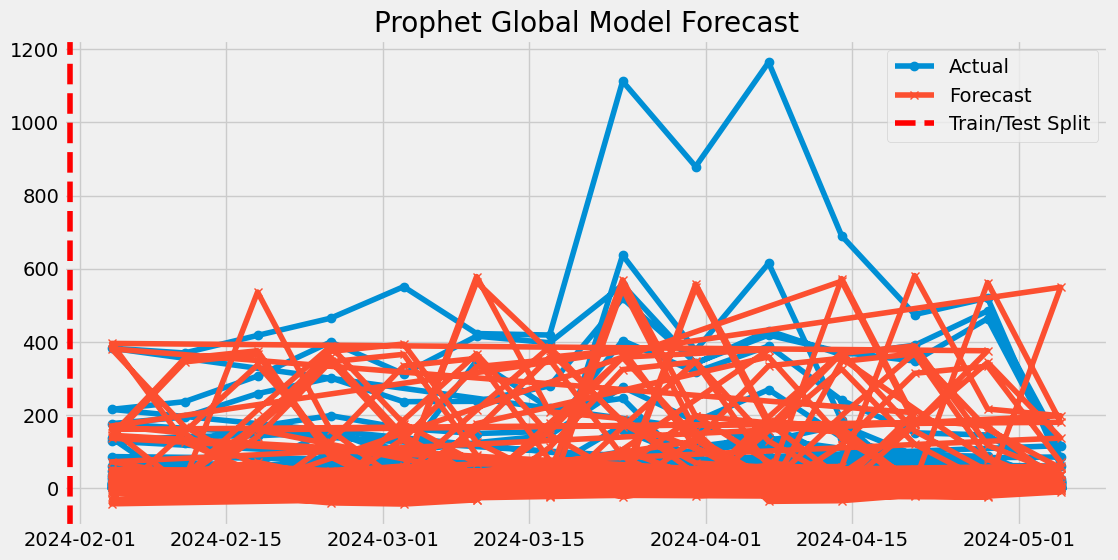

In [39]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1) Prepare Data
# ---------------------------
# Rename columns for Prophet
weekly_filtered = weekly_filtered.rename(columns={"WeekEnd": "ds", "WareHouseQuantity": "y"})
weekly_filtered["ds"] = pd.to_datetime(weekly_filtered["ds"])

# ---------------------------
# 2) Train-Test Split
# ---------------------------
train = weekly_filtered[weekly_filtered["ds"] <= "2024-02-01"].copy()
test  = weekly_filtered[weekly_filtered["ds"] >  "2024-02-01"].copy()

# ---------------------------
# 3) Add SKU as regressors
# ---------------------------
train = pd.get_dummies(train, columns=["SKU"], drop_first=True)
test  = pd.get_dummies(test,  columns=["SKU"], drop_first=True)

# Align test with train columns (important if SKUs missing in one set)
test = test.reindex(columns=train.columns, fill_value=0)

# Identify SKU dummy columns
regressors = [col for col in train.columns if col.startswith("SKU_")]

# ---------------------------
# 4) Build Prophet Model
# ---------------------------
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True, seasonality_mode='multiplicative')

# Add SKU regressors
for reg in regressors:
    m.add_regressor(reg)

# ---------------------------
# 5) Fit Model
# ---------------------------
m.fit(train[["ds","y"] + regressors])

# ---------------------------
# 6) Forecast on Test Set
# ---------------------------
future = test[["ds"] + regressors]
forecast = m.predict(future)

# Merge results
results = test[["ds","y"]].copy()
results["yhat"] = forecast["yhat"].values

# ---------------------------
# 7) Evaluate
# ---------------------------
mae = mean_absolute_error(results["y"], results["yhat"])
rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))

print("MAE:", mae)
print("RMSE:", rmse)

# ---------------------------
# 8) Plot
# ---------------------------
plt.figure(figsize=(12,6))
plt.plot(results["ds"], results["y"], label="Actual", marker="o")
plt.plot(results["ds"], results["yhat"], label="Forecast", marker="x")
plt.axvline(pd.to_datetime("2024-01-31"), color="red", linestyle="--", label="Train/Test Split")
plt.legend()
plt.title("Prophet Global Model Forecast")
plt.show()


In [40]:
# Display Actual vs Predicted
results_df = results.rename(columns={"y": "Actual_WareHouseQuantity", "yhat": "Predicted_WareHouseQuantity"})

# Add error columns
results_df["Difference"] = results_df["Predicted_WareHouseQuantity"] - results_df["Actual_WareHouseQuantity"]
results_df["Percent_Difference"] = (
    results_df["Difference"] / results_df["Actual_WareHouseQuantity"].replace(0, np.nan)
) * 100

results_df


,ds,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference,Percent_Difference
55,2024-03-10,2.0,-31.735738,-33.735738,-1686.786882
108,2024-02-04,7.0,-29.474822,-36.474822,-521.068888
109,2024-02-11,3.0,153.802857,150.802857,5026.761898
110,2024-02-18,18.0,337.464250,319.464250,1774.801389
111,2024-02-25,9.0,114.002766,105.002766,1166.697399
...,...,...,...,...,...
6402,2024-04-07,126.0,-12.059714,-138.059714,-109.571201
6403,2024-04-14,78.0,119.332322,41.332322,52.990156
6404,2024-04-21,91.0,314.472440,223.472440,245.574110
6405,2024-04-28,88.0,333.973099,245.973099,279.514885


In [ ]:
# !pip install gluonts[torch]
# !pip install torch torchvision torchaudio


  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/829.2 kB ? eta -:--:--
   ---------------------------------------- 829.2/829.2 kB 6.8 MB/s  0:00:00
   ---------------------------------------- 0.0/241.3 MB ? eta -:--:--
   ---------------------------------------- 2.4/241.3 MB 11.3 MB/s eta 0:00:22
    --------------------------------------- 4.7/241.3 MB 11.4 MB/s eta 0:00:21
   - -------------------------------------- 7.1/241.3 MB 11.5 MB/s eta 0:00:21
   - -------------------------------------- 9.4/241.3 MB 11.4 MB/s eta 0:00:21
   - -------------------------------------- 11.0/241.3 MB 10.7 MB/s eta 0:00:22
   -- ------------------------------------- 12.8/241.3 MB 10.4 MB/s eta 0:00:22
   -- ------------------------------------- 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0rc0 requires protobuf>=5.28.0, but you have protobuf 3.19.6 which is incompatible.


   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 8.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------- ----------------------- 1.0/2.5 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 7.4 MB/s  0:00:00

   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ----------------

In [48]:
# ===============================
# DeepAR (PyTorch) – Global Model
# Train:  up to 2024-01-31
# Test:   2024-02-01 onward
# Data:   weekly_filtered with columns [SKU, WeekStart, WeekEnd, WareHouseQuantity]
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# GluonTS (PyTorch backend)
from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.trainer import Trainer
from gluonts.torch.distributions import NegativeBinomialOutput
from gluonts.evaluation import make_evaluation_predictions, Evaluator

# ----------------------------------
# 1) Prepare data
# ----------------------------------
df = weekly_filtered.copy()
df = df.rename(columns={"WeekEnd": "ds", "WareHouseQuantity": "y"})
df["ds"] = pd.to_datetime(df["ds"])
df = df[["SKU", "ds", "y"]].sort_values(["SKU", "ds"]).reset_index(drop=True)

# Ensure numeric
df["y"] = pd.to_numeric(df["y"], errors="coerce").fillna(0.0)

# Optional: fill missing weeks per SKU (keeps weekly freq consistent)
# This helps DeepAR a lot when some weeks are missing in the raw data.
def fill_weekly(g):
    g = g.set_index("ds").asfreq("W-SUN")   # align to week ending Sunday (adjust if needed)
    g["SKU"] = g["SKU"].ffill().bfill()     # keep SKU label
    g["y"]   = g["y"].fillna(0.0)           # missing demand -> 0
    return g.reset_index()

df = df.groupby("SKU", group_keys=False).apply(fill_weekly)

# Split dates
SPLIT_DATE = pd.Timestamp("2024-01-31")

# Prediction horizon = number of unique test weeks after split
# (Aligned to our weekly index "W-SUN")
test_mask = df["ds"] > SPLIT_DATE
PRED_LENGTH = df.loc[test_mask, "ds"].nunique()
if PRED_LENGTH == 0:
    raise ValueError("No test weeks found after 2024-01-31. Check your data/date alignment.")

# Build SKU index for static categorical embeddings
sku_list = sorted(df["SKU"].unique().tolist())
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]
embed_dim = [min(50, max(4, len(sku_list)//2))]  # a reasonable embedding size

# ----------------------------------
# 2) Build GluonTS ListDatasets
# ----------------------------------
# Helper to create a target array up to a cutoff
def build_target(series_df, end_date=None):
    s = series_df.sort_values("ds")
    if end_date is not None:
        s = s[s["ds"] <= end_date]
    return s["y"].values.astype(float), s["ds"].min()

# Create TRAIN dataset (each SKU series truncated at SPLIT_DATE)
train_list = []
for sku in sku_list:
    g = df[df["SKU"] == sku]
    target_vals, start_ts = build_target(g, SPLIT_DATE)
    if len(target_vals) == 0:
        continue
    train_list.append({
        "item_id": sku,
        "start": pd.Timestamp(start_ts),
        "target": target_vals,
        "feat_static_cat": [sku_to_idx[sku]],
    })

train_ds = ListDataset(train_list, freq="W")

# Create TEST dataset (full history so model can roll into the test horizon)
test_list = []
for sku in sku_list:
    g = df[df["SKU"] == sku]
    target_vals, start_ts = build_target(g, None)
    if len(target_vals) == 0:
        continue
    test_list.append({
        "item_id": sku,
        "start": pd.Timestamp(start_ts),
        "target": target_vals,
        "feat_static_cat": [sku_to_idx[sku]],
    })

test_ds = ListDataset(test_list, freq="W")

# ----------------------------------
# 3) Define & Train DeepAR (global)
# - NegativeBinomialOutput -> non-negative demand
# ----------------------------------
estimator = DeepAREstimator(
    prediction_length=PRED_LENGTH,
    context_length=32,             # ~8 months of weekly context; adjust as needed
    freq="W",
    use_feat_static_cat=True,
    cardinality=cardinality,
    embedding_dimension=embed_dim,
    distr_output=NegativeBinomialOutput(),  # non-negative forecasts
    trainer=Trainer(
        epochs=50,
        learning_rate=1e-3,
        batch_size=64,
        num_batches_per_epoch=100,  # cap for speed; remove to use full data each epoch
    ),
)

predictor = estimator.train(training_data=train_ds)

# ----------------------------------
# 4) Forecast on Test set
# ----------------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100,  # MC samples for quantiles
)

forecasts = list(forecast_it)
tss = list(ts_it)  # historical series (full)

# ----------------------------------
# 5) Evaluation (aggregate + per-item)
# ----------------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5, 0.9])
agg_metrics, item_metrics = evaluator(tss, forecasts)
print("\nAggregate metrics (DeepAR):")
print(pd.Series(agg_metrics).round(4))

# ----------------------------------
# 6) Build Actual vs Predicted table (per SKU & week)
#    P50 used as point forecast
# ----------------------------------
all_rows = []

# We know we created test_ds in the same order as sku_list, so we can pair them safely
for idx, sku in enumerate(sku_list):
    f = forecasts[idx]

    # Forecast horizon timestamps
    pred_index = pd.period_range(f.start_date, periods=f.prediction_length, freq=f.freq).to_timestamp()

    # Extract P50 (median) as point forecast (or use f.mean for mean)
    yhat_p50 = f.quantile(0.5)

    # Keep only the test period (after SPLIT_DATE)
    mask = pred_index > SPLIT_DATE
    pred_index = pred_index[mask]
    yhat_p50 = yhat_p50[-len(pred_index):]  # align to the filtered horizon

    # Actuals for comparison
    actual = (
        df[(df["SKU"] == sku) & (df["ds"].isin(pred_index))]
        .set_index("ds")["y"]
        .reindex(pred_index, fill_value=np.nan)
        .values
    )

    # Build rows
    for ds_i, a, p in zip(pred_index, actual, yhat_p50):
        diff = p - a if pd.notnull(a) else np.nan
        pct_diff = (diff / a * 100) if (pd.notnull(a) and a != 0) else np.nan
        all_rows.append({
            "SKU": sku,
            "ds": ds_i,
            "Actual_WareHouseQuantity": a,
            "Predicted_WareHouseQuantity": float(p),
            "Difference": float(diff) if pd.notnull(diff) else np.nan,
            "Percent_Difference": float(pct_diff) if pd.notnull(pct_diff) else np.nan,
        })

results_df = pd.DataFrame(all_rows).sort_values(["SKU", "ds"]).reset_index(drop=True)
print("\nResults sample:")
print(results_df.head(10))

# Save to file
results_df.to_csv("deepar_global_results.csv", index=False)
print("\nSaved: deepar_global_results.csv")

# ----------------------------------
# 7) Quick plot for one SKU
# ----------------------------------
plot_sku = sku_list[0]  # change to any SKU you want to visualize
hist = df[df["SKU"] == plot_sku].set_index("ds")["y"]
pred_sku = results_df[results_df["SKU"] == plot_sku].set_index("ds")["Predicted_WareHouseQuantity"]

plt.figure(figsize=(12,5))
hist.plot(label="Actual (history)", linewidth=2)
pred_sku.plot(label="Forecast (P50)", linestyle="--")
plt.axvline(pd.to_datetime("2024-01-31"), color="red", linestyle="--", label="Train/Test Split")
plt.title(f"DeepAR Forecast — {plot_sku}")
plt.legend()
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'gluonts.torch.trainer'

In [ ]:
# Install required packages
# !pip install gluonts torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.training.trainer import Trainer  # ✅ Correct import
from gluonts.torch.distributions import NegativeBinomialOutput
from gluonts.evaluation import make_evaluation_predictions, Evaluator

# ------------------------------
# 1) Prepare your dataset
# ------------------------------
# Assume weekly_filtered already exists
# Columns: SKU, WeekStart, WeekEnd, WareHouseQuantity

# Convert dates
weekly_filtered["WeekStart"] = pd.to_datetime(weekly_filtered["WeekStart"])
weekly_filtered["WeekEnd"] = pd.to_datetime(weekly_filtered["WeekEnd"])

# Sort
weekly_filtered = weekly_filtered.sort_values(["SKU", "WeekStart"])

# ------------------------------
# 2) Train/Test Split
# ------------------------------
HORIZON = 8  # forecast horizon
train_data = []
test_data = []

for sku, group in weekly_filtered.groupby("SKU"):
    group = group.reset_index(drop=True)
    
    # train up to last HORIZON weeks
    train_df = group.iloc[:-HORIZON]
    test_df  = group
    
    # Train dataset
    train_data.append({
        "start": train_df["WeekStart"].iloc[0],
        "target": train_df["WareHouseQuantity"].values,
        "item_id": sku
    })
    
    # Test dataset (full series, to forecast last HORIZON)
    test_data.append({
        "start": group["WeekStart"].iloc[0],
        "target": group["WareHouseQuantity"].values,
        "item_id": sku
    })

train_ds = ListDataset(train_data, freq="W")
test_ds  = ListDataset(test_data, freq="W")

# ------------------------------
# 3) Define and Train DeepAR
# ------------------------------
estimator = DeepAREstimator(
    freq="W",
    prediction_length=HORIZON,
    trainer=Trainer(epochs=20, learning_rate=1e-3, batch_size=32),
    distr_output=NegativeBinomialOutput()
)

predictor = estimator.train(training_data=train_ds)

# ------------------------------
# 4) Forecast & Evaluate
# ------------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100,
)

forecasts = list(forecast_it)
tss = list(ts_it)

evaluator = Evaluator()
agg_metrics, item_metrics = evaluator(tss, forecasts)

print("Aggregate Metrics:")
print(agg_metrics)

# ------------------------------
# 5) Plot Example Forecast
# ------------------------------
sku_idx = 0  # pick one SKU to visualize
tss[sku_idx].plot(label="actual")
forecasts[sku_idx].plot(color="g")
plt.legend()
plt.show()


ModuleNotFoundError: No module named 'gluonts.torch.training'

In [ ]:
# pip install gluonts[pytorch]==0.16.2 torch


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------- ----- 1.3/1.5 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 6.8 MB/s  0:00:00
  Attempting uninstall: gluonts
    Found existing installation: gluonts 0.13.3
    Uninstalling gluonts-0.13.3:
      Successfully uninstalled gluonts-0.13.3
Note: you may need to restart the kernel to use updated packages.


In [157]:
import pandas as pd
import numpy as np

def create_time_series_features(df, date_col="WeekEnd", target_col="WareHouseQuantity", group_col="SKU"):
    """
    Create time-series features (date-based, cyclic, lag, rolling) for LSTM/ML models.
    
    Parameters:
        df (pd.DataFrame): Input dataframe with columns [SKU, WeekEnd, WareHouseQuantity]
        date_col (str): Date column name (default = 'WeekEnd')
        target_col (str): Target column name (default = 'WareHouseQuantity')
        group_col (str): Grouping column (default = 'SKU')
    
    Returns:
        pd.DataFrame: Feature engineered dataframe
    """
    
    df = df.copy()
    
    # Ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values([group_col, date_col])
    
    # Calendar features
    df["week"] = df[date_col].dt.isocalendar().week.astype(int)
    df["month"] = df[date_col].dt.month
    df["quarter"] = df[date_col].dt.quarter
    df["year"] = df[date_col].dt.year
    
    # Cyclic encoding
    df["week_sin"] = np.sin(2 * np.pi * df["week"] / 52)
    df["week_cos"] = np.cos(2 * np.pi * df["week"] / 52)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    
    # Lag features
    for lag in [1, 2, 3]:
        df[f"lag{lag}"] = df.groupby(group_col)[target_col].shift(lag)
    
    # Rolling features
    df["rolling_mean_3"] = df.groupby(group_col)[target_col].shift(1).rolling(3).mean()
    df["rolling_std_3"] = df.groupby(group_col)[target_col].shift(1).rolling(3).std()
    
    # Drop NA rows created by lag/rolling
    df = df.dropna().reset_index(drop=True)
    
    return df


In [158]:
weekly_features = create_time_series_features(weekly_filtered)

weekly_features


,SKU,WeekStart,WeekEnd,WareHouseQuantity,week,month,quarter,year,week_sin,week_cos,month_sin,month_cos,lag1,lag2,lag3,rolling_mean_3,rolling_std_3
0,10AD01FNA02,2023-02-13,2023-02-19,39.0,7,2,1,2023,0.748511,0.663123,0.866025,5.000000e-01,26.0,31.0,24.0,27.000000,3.605551
1,10AD01FNA02,2023-02-20,2023-02-26,22.0,8,2,1,2023,0.822984,0.568065,0.866025,5.000000e-01,39.0,26.0,31.0,32.000000,6.557439
2,10AD01FNA02,2023-02-27,2023-03-05,4.0,9,3,1,2023,0.885456,0.464723,1.000000,6.123234e-17,22.0,39.0,26.0,29.000000,8.888194
3,10AD01FNA02,2023-03-06,2023-03-12,8.0,10,3,1,2023,0.935016,0.354605,1.000000,6.123234e-17,4.0,22.0,39.0,21.666667,17.502381
4,10AD01FNA02,2023-03-13,2023-03-19,12.0,11,3,1,2023,0.970942,0.239316,1.000000,6.123234e-17,8.0,4.0,22.0,11.333333,9.451631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4521,90AD550AD01,2024-04-01,2024-04-07,126.0,14,4,2,2024,0.992709,-0.120537,0.866025,-5.000000e-01,102.0,101.0,66.0,89.666667,20.502032
4522,90AD550AD01,2024-04-08,2024-04-14,78.0,15,4,2,2024,0.970942,-0.239316,0.866025,-5.000000e-01,126.0,102.0,101.0,109.666667,14.153916
4523,90AD550AD01,2024-04-15,2024-04-21,91.0,16,4,2,2024,0.935016,-0.354605,0.866025,-5.000000e-01,78.0,126.0,102.0,102.000000,24.000000
4524,90AD550AD01,2024-04-22,2024-04-28,88.0,17,4,2,2024,0.885456,-0.464723,0.866025,-5.000000e-01,91.0,78.0,126.0,98.333333,24.826062


### Model Building

Take all the data for training except last 8 weeks

So for each SKU:

- **Training set** = all weeks except the last 8 weeks.
- **Testing set** = the last 8 weeks only.

In [159]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Flatten
from tensorflow.keras.models import Model

# ---------------------------
# CONFIG
# ---------------------------
LOOKBACK = 8               # weeks of history per sequence
CUTOFF_DATE = "2024-01-01" # split by time
TARGET_COL = "WareHouseQuantity"
GROUP_COL  = "SKU"
DATE_COL   = "WeekEnd"

# Which columns are used as numeric features per timestep (exclude IDs/dates/target)
EXCLUDE_COLS = [GROUP_COL, "WeekStart", DATE_COL, TARGET_COL]



In [160]:
def time_split(df, cutoff_date, date_col=DATE_COL):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    train_df = df[df[date_col] < pd.to_datetime(cutoff_date)].copy()
    test_df  = df[df[date_col] >= pd.to_datetime(cutoff_date)].copy()
    return train_df.sort_values([GROUP_COL, date_col]), test_df.sort_values([GROUP_COL, date_col])


In [161]:
def fit_scale_features(train_df, test_df, exclude_cols=EXCLUDE_COLS):
    feature_cols = [c for c in train_df.columns if c not in exclude_cols]
    # Also remove any non-numeric columns that might sneak in
    feature_cols = [c for c in feature_cols if np.issubdtype(train_df[c].dtype, np.number)]

    scaler = StandardScaler()
    train_df_scaled = train_df.copy()
    test_df_scaled  = test_df.copy()

    train_df_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    test_df_scaled[feature_cols]  = scaler.transform(test_df[feature_cols])
    return train_df_scaled, test_df_scaled, feature_cols, scaler


In [162]:
def build_sequences(df, feature_cols, lookback=LOOKBACK, group_col=GROUP_COL, target_col=TARGET_COL, date_col=DATE_COL):
    """
    Build sequences strictly within df (already split as train or test).
    Returns:
      X   -> (samples, lookback, n_features)
      y   -> (samples,)
      sku -> (samples, 1) integer-encoded (caller encodes)
      idx -> list of (sku, end_date) for each sample (optional tracking)
    """
    X_list, y_list, sku_list, idx_list = [], [], [], []

    for sku, g in df.groupby(group_col):
        g = g.sort_values(date_col)
        values = g[feature_cols].values
        target = g[target_col].values
        dates  = g[date_col].values

        # Create windows entirely inside this split to avoid leakage
        if len(g) <= lookback:
            continue
        for i in range(len(g) - lookback):
            X_list.append(values[i:i+lookback])
            y_list.append(target[i+lookback])
            sku_list.append(sku)
            idx_list.append((sku, dates[i+lookback]))

    X = np.array(X_list)
    y = np.array(y_list)
    return X, y, np.array(sku_list), idx_list


In [163]:
def encode_skus(all_skus_series):
    le = LabelEncoder()
    sku_ids = le.fit_transform(all_skus_series)
    return le, sku_ids


In [223]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------------
# Parameters
# -------------------------------
LOOKBACK = 5   # how many past weeks to use
FORECAST_HORIZON = 1
BATCH_SIZE = 256
EPOCHS = 100

# -------------------------------
# Encode SKUs
# -------------------------------
le = LabelEncoder()
weekly_features["SKU_enc"] = le.fit_transform(weekly_features["SKU"])
n_skus = weekly_features["SKU_enc"].nunique()

# Scale warehouse quantity
scaler = MinMaxScaler()
weekly_features["WareHouseQuantity_scaled"] = scaler.fit_transform(weekly_features[["WareHouseQuantity"]])

# -------------------------------
# Sequence creation
# -------------------------------
def create_sequences(df, lookback, horizon):
    X_seq, X_sku, y = [], [], []
    for sku in df["SKU_enc"].unique():
        temp = df[df["SKU_enc"] == sku].reset_index(drop=True)
        values = temp["WareHouseQuantity_scaled"].values
        for i in range(len(values) - lookback - horizon + 1):
            X_seq.append(values[i:i+lookback])
            X_sku.append(temp.loc[i+lookback-1, "SKU_enc"])
            y.append(values[i+lookback:i+lookback+horizon])
    return np.array(X_seq), np.array(X_sku), np.array(y)

X_seq, X_sku, y = create_sequences(weekly_features, LOOKBACK, FORECAST_HORIZON)

# Reshape for LSTM
X_seq = X_seq.reshape((X_seq.shape[0], LOOKBACK, 1))

# -------------------------------
# Train/test split
# -------------------------------
split = int(len(X_seq) * 0.8)
X_seq_train, X_seq_test = X_seq[:split], X_seq[split:]
X_sku_train, X_sku_test = X_sku[:split], X_sku[split:]
y_train, y_test = y[:split], y[split:]

# -------------------------------
# Model
# -------------------------------
seq_input = Input(shape=(LOOKBACK, 1), name="seq_input")
x = LSTM(256, return_sequences=False)(seq_input)
x = Dense(256, activation="mish")(x)

sku_input = Input(shape=(1,), name="sku_input")
embed_dim = min(16, max(4, n_skus // 10))
sku_embed = Embedding(input_dim=n_skus, output_dim=embed_dim)(sku_input)
sku_embed = Dense(256, activation="mish")(sku_embed)
sku_embed = Dense(16, activation="mish")(sku_embed)
sku_embed = Dense(64, activation="mish")(sku_embed)

sku_embed = sku_embed[:, -1, :]  # flatten embedding

combined = Concatenate()([x, sku_embed])
output = Dense(FORECAST_HORIZON)(combined)

model = Model(inputs=[seq_input, sku_input], outputs=output)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.008)
model.compile(optimizer="adam", loss="mse")

# -------------------------------
# Callbacks
# -------------------------------
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lr_plateau = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# -------------------------------
# Training
# -------------------------------
history = model.fit(
    [X_seq_train, X_sku_train],
    y_train,
    validation_data=([X_seq_test, X_sku_test], y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, lr_plateau],
    verbose=1
)

# -------------------------------
# Predictions
# -------------------------------
y_pred_scaled = model.predict([X_seq_test, X_sku_test])

# Inverse scaling (back to original WareHouseQuantity scale)
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# -------------------------------
# Metrics
# -------------------------------
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0014 - val_loss: 9.0568e-04 - learning_rate: 0.0010
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.4166e-04 - val_loss: 8.2182e-04 - learning_rate: 0.0010
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8.4984e-04 - val_loss: 7.5895e-04 - learning_rate: 0.0010
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.8044e-04 - val_loss: 7.1508e-04 - learning_rate: 0.0010
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 7.7145e-04 - val_loss: 7.0255e-04 - learning_rate: 0.0010
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 7.6516e-04 - val_loss: 7.0513e-04 - learning_rate: 0.0010
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 7.1522e-04 - val_loss: 6.8544e-04 - learning_rate: 0.0010
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 6.7042e-04 - val_loss: 7.1399e-04 - learning_rate: 0.0010
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 

In [224]:




# -------------------------------
# ±10% Accuracy Check
# -------------------------------
lower_bound = y_true * 0.9
upper_bound = y_true * 1.1
within_10pct = np.logical_and(y_pred >= lower_bound, y_pred <= upper_bound)

accuracy_10pct = np.mean(within_10pct) * 100
print(f"Predictions within ±10% of actual: {accuracy_10pct:.2f}%")


Predictions within ±10% of actual: 9.47%


In [ ]:
# # Ensure datetime and sorted
# df_feat = weekly_features.copy()
# df_feat[DATE_COL] = pd.to_datetime(df_feat[DATE_COL])
# df_feat = df_feat.sort_values([GROUP_COL, DATE_COL])

# # 1) Time split
# train_df, test_df = time_split(df_feat, CUTOFF_DATE)

# # 2) Scale (fit only on train; apply to test)
# train_scaled, test_scaled, feature_cols, scaler = fit_scale_features(train_df, test_df, EXCLUDE_COLS)

# # 3) Build sequences
# X_train, y_train, sku_train_str, idx_train = build_sequences(train_scaled, feature_cols, LOOKBACK)
# X_test,  y_test,  sku_test_str,  idx_test  = build_sequences(test_scaled,  feature_cols, LOOKBACK)

# # 4) SKU encoding (fit on ALL SKUs to keep mapping stable)
# le = LabelEncoder()
# le.fit(df_feat[GROUP_COL])

# sku_train = le.transform(sku_train_str).reshape(-1, 1)
# sku_test  = le.transform(sku_test_str).reshape(-1, 1)

# n_features = X_train.shape[2]
# n_skus = len(le.classes_)

# print("Train shapes:", X_train.shape, y_train.shape, sku_train.shape)
# print("Test  shapes:", X_test.shape,  y_test.shape,  sku_test.shape)
# print("Features used:", feature_cols)


Train shapes: (3676, 8, 13) (3676,) (3676, 1)
Test  shapes: (244, 8, 13) (244,) (244, 1)
Features used: ['week', 'month', 'quarter', 'year', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'lag1', 'lag2', 'lag3', 'rolling_mean_3', 'rolling_std_3']


In [131]:
y_train

array([  4.,   9.,   6., ..., 123.,  95.,  98.], shape=(3676,))

In [ ]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Flatten, Concatenate, Dropout
# from tensorflow.keras.models import Model
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# # ---------------------------
# # MODEL
# # ---------------------------
# def build_model(LOOKBACK, n_features, n_skus):
#     # Sequential (time-series) path
#     seq_input = Input(shape=(LOOKBACK, n_features), name="seq_input")

#     x = LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(seq_input)
#     x = LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(x)
#     x = Dense(64, activation="relu")(x)
#     x = Dropout(0.3)(x)
#     x = Dense(32, activation="relu")(x)

#     # SKU embedding path
#     sku_input = Input(shape=(1,), name="sku_input")
#     embed_dim = min(32, max(8, n_skus // 4))  # improved heuristic
#     e = Embedding(input_dim=n_skus, output_dim=embed_dim, name="sku_embedding")(sku_input)
#     e = Flatten()(e)
#     e = Dense(32, activation="relu")(e)

#     # Merge
#     z = Concatenate()([x, e])
#     z = Dense(64, activation="relu")(z)
#     z = Dropout(0.3)(z)
#     out = Dense(1, name="y")(z)

#     model = Model(inputs=[seq_input, sku_input], outputs=out)
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
#         loss="mse",
#         metrics=[tf.keras.metrics.MAE, tf.keras.metrics.MAPE]
#     )
#     return model

# # ---------------------------
# # CALLBACKS
# # ---------------------------
# early_stop = EarlyStopping(
#     monitor="val_loss", 
#     patience=10, 
#     restore_best_weights=True
# )

# reduce_lr = ReduceLROnPlateau(
#     monitor="val_loss", 
#     factor=0.5, 
#     patience=5, 
#     min_lr=1e-5
# )

# # ---------------------------
# # BUILD & TRAIN
# # ---------------------------
# model = build_model(LOOKBACK, n_features, n_skus)
# model.summary()

# history = model.fit(
#     [X_train, sku_train_str], y_train,
#     validation_data=([X_test, sku_test_str], y_test),
#     epochs=100,
#     batch_size=64,
#     callbacks=[early_stop, reduce_lr],
#     verbose=1
# )


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 8, 13)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 8, 128)    │     72,704 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 64)        │     49,408 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sku_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      4,160 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sku_embedding       │ (None, 1, 10)     │        400 │ sku_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 10)        │          0 │ sku_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │        352 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ dense_8[0][0],    │
│ (Concatenate)       │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      4,160 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y (Dense)           │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 133,329 (520.82 KB)

 Trainable params: 133,329 (520.82 KB)

 Non-trainable params: 0 (0.00 B)

ValueError: Invalid dtype: str416

In [ ]:
history = model.fit(
    {"seq_input": X_train, "sku_input": sku_train},
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,   # takes the last 20% (because shuffle=False)
    shuffle=False,
    verbose=1
)

# Evaluate on test
test_loss, test_mae, test_mape = model.evaluate({"seq_input": X_test, "sku_input": sku_test}, y_test, verbose=0)
print(f"Test -> MSE: {test_loss:.3f}, MAE: {test_mae:.3f}, MAPE: {test_mape:.2f}%")

# Extra metrics
y_pred_test = model.predict({"seq_input": X_test, "sku_input": sku_test}, verbose=0).ravel()
mse  = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)   # Manual RMSE
mae  = mean_absolute_error(y_test, y_pred_test)

print(f"Test RMSE: {rmse:.3f}, MAE: {mae:.3f}")


Epoch 1/50


23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 146893.4375 - mean_absolute_error: 152.4206 - mean_absolute_percentage_error: 97.4624 - val_loss: 135402.5469 - val_mean_absolute_error: 163.2535 - val_mean_absolute_percentage_error: 89.5817
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 144024.2500 - mean_absolute_error: 146.7135 - mean_absolute_percentage_error: 137.3228 - val_loss: 132595.2969 - val_mean_absolute_error: 158.5169 - val_mean_absolute_percentage_error: 109.6823
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 137156.6094 - mean_absolute_error: 140.8957 - mean_absolute_percentage_error: 297.0470 - val_loss: 124687.3594 - val_mean_absolute_error: 149.9494 - val_mean_absolute_percentage_error: 217.8356
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 127335.8438 - mean_absolute_error: 139.4624 - mean_absolute_percentage_error: 510.1599 - val_loss: 114577.6172 - val_mean_absolute_error: 140.8197 - val_mean_absolute_percentage_error: 274.3860
E

In [77]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_test
})

# Difference
results_df["Error"] = results_df["Predicted"] - results_df["Actual"]

print(results_df.head(10))


   Actual  Predicted      Error
0    10.0  25.294592  15.294592
1    10.0  25.327051  15.327051
2    18.0  25.361559   7.361559
3    10.0  25.395658  15.395658
4     8.0  25.423403  17.423403
5    11.0  25.439993  14.439993
6     7.0  25.447149  18.447149
7    12.0  25.385687  13.385687
8     7.0  25.386400  18.386400
9     1.0  25.378443  24.378443


In [79]:
import pandas as pd
import numpy as np

# 5) Predict on test set
y_pred = model.predict([X_test, sku_test])   # (depending on how you pass SKU as input)
y_pred = y_pred.flatten()

# 6) Build results DataFrame
results_df = pd.DataFrame({
    "SKU": le.inverse_transform(sku_test.flatten()),
    "WeekEnd": [idx[-1] for idx in idx_test],   # last date in each sequence
    "Actual_WareHouseQuantity": y_test.flatten(),
    "Predicted_WareHouseQuantity": np.round(y_pred).astype(int)
})

# 7) Add evaluation metrics
results_df["Difference_Between_Predicted_And_Actual"] = (
    results_df["Predicted_WareHouseQuantity"] - results_df["Actual_WareHouseQuantity"]
)
results_df["Percent_Difference"] = (
    100 * results_df["Difference_Between_Predicted_And_Actual"] / results_df["Actual_WareHouseQuantity"].replace(0, np.nan)
)

# Define ±10% thresholds
results_df["Minus_10_Percent"] = results_df["Actual_WareHouseQuantity"] * 0.9
results_df["Plus_10_Percent"]  = results_df["Actual_WareHouseQuantity"] * 1.1
results_df["Within_10_Percent"] = (
    (results_df["Predicted_WareHouseQuantity"] >= results_df["Minus_10_Percent"]) &
    (results_df["Predicted_WareHouseQuantity"] <= results_df["Plus_10_Percent"])
)
results_df["Within_10_Percent"]= np.where(results_df["Within_10_Percent"], "Acceptable", "Out of Range")

# Business Accuracy Calculation
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

results_df.to_csv("LSTM_Predictions.csv")

results_df


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Business Accuracy (±10% rule): 0.00%


,SKU,WeekEnd,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNB02,2024-03-03,10.0,0,-10.0,-100.0,9.0,11.0,Out of Range
1,10AD01FNB02,2024-03-10,10.0,0,-10.0,-100.0,9.0,11.0,Out of Range
2,10AD01FNB02,2024-03-17,18.0,0,-18.0,-100.0,16.2,19.8,Out of Range
3,10AD01FNB02,2024-03-24,10.0,0,-10.0,-100.0,9.0,11.0,Out of Range
4,10AD01FNB02,2024-03-31,8.0,0,-8.0,-100.0,7.2,8.8,Out of Range
...,...,...,...,...,...,...,...,...,...
239,90AD550AD01,2024-04-07,126.0,0,-126.0,-100.0,113.4,138.6,Out of Range
240,90AD550AD01,2024-04-14,78.0,0,-78.0,-100.0,70.2,85.8,Out of Range
241,90AD550AD01,2024-04-21,91.0,0,-91.0,-100.0,81.9,100.1,Out of Range
242,90AD550AD01,2024-04-28,88.0,0,-88.0,-100.0,79.2,96.8,Out of Range


In [73]:
X_train

array([[[-1.4714285 , -1.47323918, -1.52509099, ..., -0.36318812,
         -0.39633594, -0.33917354],
        [-1.40381473, -1.47323918, -1.52509099, ..., -0.34235612,
         -0.37975461, -0.32190339],
        [-1.33620097, -1.18043784, -1.52509099, ..., -0.35723612,
         -0.38970341, -0.3082672 ],
        ...,
        [-1.13335967, -1.18043784, -1.52509099, ..., -0.42270811,
         -0.45934502, -0.3368658 ],
        [-1.06574591, -0.8876365 , -0.61793654, ..., -0.41080411,
         -0.41070643, -0.23137881],
        [-0.99813214, -0.8876365 , -0.61793654, ..., -0.39890011,
         -0.4040739 , -0.24189982]],

       [[-1.40381473, -1.47323918, -1.52509099, ..., -0.34235612,
         -0.37975461, -0.32190339],
        [-1.33620097, -1.18043784, -1.52509099, ..., -0.35723612,
         -0.38970341, -0.3082672 ],
        [-1.2685872 , -1.18043784, -1.52509099, ..., -0.31854812,
         -0.4140227 , -0.25786951],
        ...,
        [-1.06574591, -0.8876365 , -0.61793654, ..., -

In [285]:


# 4) Store results in dataframe
pred_df = test[["SKU","WeekEnd"]].copy()
pred_df["Actual_WareHouseQuantity"] = test["WareHouseQuantity"].values

# Convert predictions to integers
pred_df["Predicted_WareHouseQuantity"] = np.round(y_pred).astype(int)

# 6) Add extra evaluation columns
pred_df["Difference_Between_Predicted_And_Actual"] = (
    pred_df["Predicted_WareHouseQuantity"] - pred_df["Actual_WareHouseQuantity"]
)

pred_df["Percent_Difference"] = (
    (pred_df["Difference_Between_Predicted_And_Actual"] / pred_df["Actual_WareHouseQuantity"]) * 100
).round(2)

# Apply ceiling on tolerance bounds
pred_df["Minus_10_Percent"] = np.ceil(pred_df["Actual_WareHouseQuantity"] * 0.9).astype(int)
pred_df["Plus_10_Percent"]  = np.ceil(pred_df["Actual_WareHouseQuantity"] * 1.1).astype(int)

# Acceptable vs Out of Range
within_10 = (
    (pred_df["Predicted_WareHouseQuantity"] >= pred_df["Minus_10_Percent"]) &
    (pred_df["Predicted_WareHouseQuantity"] <= pred_df["Plus_10_Percent"])
)
pred_df["Within_10_Percent"] = np.where(within_10, "Acceptable", "Out of Range")

# 7) Business Accuracy Calculation
business_accuracy = (pred_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

pred_df.to_csv("Predictions.csv")

# Show final dataframe
pred_df


Business Accuracy (±10% rule): 21.49%


,SKU,WeekEnd,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2024-01-28,4.0,15,11.0,275.00,4,5,Out of Range
1,10AD01FNA02,2024-03-10,2.0,17,15.0,750.00,2,3,Out of Range
2,10AD01FNB02,2024-03-17,18.0,14,-4.0,-22.22,17,20,Out of Range
3,10AD01FNB02,2024-03-24,10.0,21,11.0,110.00,9,11,Out of Range
4,10AD01FNB02,2024-03-31,8.0,22,14.0,175.00,8,9,Out of Range
...,...,...,...,...,...,...,...,...,...
223,90AD550AD01,2024-04-07,126.0,124,-2.0,-1.59,114,139,Acceptable
224,90AD550AD01,2024-04-14,78.0,110,32.0,41.03,71,86,Out of Range
225,90AD550AD01,2024-04-21,91.0,81,-10.0,-10.99,82,101,Out of Range
226,90AD550AD01,2024-04-28,88.0,101,13.0,14.77,80,97,Out of Range


In [32]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from math import sqrt

HORIZON = 8
results_all = []

# 1) Split train/test across ALL SKUs
train = weekly_feat.groupby("SKU", group_keys=False).apply(lambda g: g.iloc[:-HORIZON]).reset_index(drop=True)  # Groups the dataset per SKU (so each SKU’s history is handled separately).
test  = weekly_feat.groupby("SKU", group_keys=False).apply(lambda g: g.iloc[-HORIZON:]).reset_index(drop=True)

X_train, y_train = train[feature_cols], train["WareHouseQuantity"]
X_test,  y_test  = test[feature_cols], test["WareHouseQuantity"]

# 2) Train ONE global model
global_model = XGBRegressor(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.9,
    colsample_bytree=0.3,
    reg_lambda=0.3,
    min_child_weight=2,
    max_delta_step=1,
    random_state=42
)
global_model.fit(X_train, y_train)

# 3) Predict on last 8 weeks per SKU
y_pred = global_model.predict(X_test)
y_pred = np.clip(y_pred, a_min=0, a_max=None)  # avoid negatives

# 4) Store results in dataframe
# pred_df = test[["SKU","WeekEnd"]].copy()
# pred_df["Predicted_WareHouseQuantity"] = y_pred

# 5) Evaluate overall error
mae  = mean_absolute_error(y_test, y_pred)
rmse = sqrt(np.mean((y_test - y_pred)**2))
print(f"Global Model Performance: MAE={mae:.2f}, RMSE={rmse:.2f}")




C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_23544\2096633828.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = weekly_feat.groupby("SKU", group_keys=False).apply(lambda g: g.iloc[:-HORIZON]).reset_index(drop=True)  # Groups the dataset per SKU (so each SKU’s history is handled separately).
C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_23544\2096633828.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence t

Global Model Performance: MAE=83.46, RMSE=186.14


In [34]:


# 4) Store results in dataframe
pred_df = test[["SKU","WeekEnd"]].copy()
pred_df["Actual_WareHouseQuantity"] = test["WareHouseQuantity"].values

# Convert predictions to integers
pred_df["Predicted_WareHouseQuantity"] = np.round(y_pred).astype(int)

# 6) Add extra evaluation columns
pred_df["Difference_Between_Predicted_And_Actual"] = (
    pred_df["Predicted_WareHouseQuantity"] - pred_df["Actual_WareHouseQuantity"]
)

pred_df["Percent_Difference"] = (
    (pred_df["Difference_Between_Predicted_And_Actual"] / pred_df["Actual_WareHouseQuantity"]) * 100
).round(2)

# Apply ceiling on tolerance bounds
pred_df["Minus_10_Percent"] = np.ceil(pred_df["Actual_WareHouseQuantity"] * 0.9).astype(int)
pred_df["Plus_10_Percent"]  = np.ceil(pred_df["Actual_WareHouseQuantity"] * 1.1).astype(int)

# Acceptable vs Out of Range
within_10 = (
    (pred_df["Predicted_WareHouseQuantity"] >= pred_df["Minus_10_Percent"]) &
    (pred_df["Predicted_WareHouseQuantity"] <= pred_df["Plus_10_Percent"])
)
pred_df["Within_10_Percent"] = np.where(within_10, "Acceptable", "Out of Range")

# 7) Business Accuracy Calculation
business_accuracy = (pred_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

# Show final dataframe
pred_df


Business Accuracy (±10% rule): 7.46%


,SKU,WeekEnd,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2024-01-28,4.0,9,5.0,125.00,4,5,Out of Range
1,10AD01FNA02,2024-03-10,2.0,8,6.0,300.00,2,3,Out of Range
2,10AD01FNB02,2024-03-17,18.0,9,-9.0,-50.00,17,20,Out of Range
3,10AD01FNB02,2024-03-24,10.0,9,-1.0,-10.00,9,11,Acceptable
4,10AD01FNB02,2024-03-31,8.0,9,1.0,12.50,8,9,Acceptable
...,...,...,...,...,...,...,...,...,...
223,90AD550AD01,2024-04-07,126.0,9,-117.0,-92.86,114,139,Out of Range
224,90AD550AD01,2024-04-14,78.0,9,-69.0,-88.46,71,86,Out of Range
225,90AD550AD01,2024-04-21,91.0,9,-82.0,-90.11,82,101,Out of Range
226,90AD550AD01,2024-04-28,88.0,9,-79.0,-89.77,80,97,Out of Range


In [250]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ========== STEP 1: Build sequences ==========
seq_len = 8   # number of past weeks to look back
sku_data = []

for sku, g in weekly.groupby("SKU"):
    g = g.sort_values("WeekEnd")   # keep time order
    series = g["WareHouseQuantity"].values.astype(float)

    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i+seq_len])
        y.append(series[i+seq_len])

    if len(X) > 0:   # only keep SKUs with enough history
        X = np.array(X).reshape(-1, seq_len)   # (samples, seq_len)
        y = np.array(y)
        sku_data.append((X, y))

# Combine across SKUs
X_all = np.concatenate([d[0] for d in sku_data], axis=0)
y_all = np.concatenate([d[1] for d in sku_data], axis=0)

# Add feature dimension for LSTM
X_all = np.expand_dims(X_all, axis=-1)   # (samples, seq_len, 1)

print("Final shapes:", X_all.shape, y_all.shape)


# ========== STEP 2: Train / Test Split ==========
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, shuffle=True, random_state=42
)


# ========== STEP 3: Build LSTM Model ==========
model = Sequential([
    LSTM(64, input_shape=(seq_len, 1), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1)   # regression output
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


# ========== STEP 4: Train ==========
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)


# ========== STEP 5: Evaluate ==========
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.4f}, Test MAE: {test_mae:.4f}")


Final shapes: (6123, 8, 1) (6123,)


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 225373.6875 - mae: 184.1716 - val_loss: 198408.7812 - val_mae: 149.8739
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 195609.2812 - mae: 150.4278 - val_loss: 171179.5469 - val_mae: 123.8627
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 166087.8906 - mae: 127.1325 - val_loss: 147365.3281 - val_mae: 105.4743
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 142011.9219 - mae: 115.2424 - val_loss: 132777.4375 - val_mae: 98.1595
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 133173.8438 - mae: 110.9144 - val_loss: 127515.2812 - val_mae: 95.1753
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 119594.9531 - mae: 105.4256 - val_loss: 116884.2188 - val_mae: 93.3025
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 108291.4922 - mae: 101.1167 - val_loss: 111346.1953 - val_mae: 93.3197
Epoch 8/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 103597.9453 - mae: 9